In [1]:
# CELL 1: Imports
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import tifffile
from skimage import morphology, measure
from scipy import ndimage

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import os
import gc
import zipfile

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
# CELL 2: Configuration
class Config:
    # Data paths
    DATA_ROOT = Path('/kaggle/input/vesuvius-challenge-surface-detection')
    TEST_CSV = DATA_ROOT / 'test.csv'
    TEST_IMAGES = DATA_ROOT / 'test_images'
    MODEL_PATH = '/kaggle/input/unet2-5segment/pytorch/default/4/best_model.pth'
    
    # Model architecture
    IN_CHANNELS_2_5D = 7
    NUM_CLASSES = 3
    BASE_FEATURES = 24
    PATCH_SIZE = 128
    
    # Inference settings
    BATCH_SIZE = 64
    NUM_WORKERS = 0
    OVERLAP = 0.25
    
    # Output
    OUTPUT_DIR = Path('/kaggle/working/submission_tifs')
    SUBMISSION_ZIP = 'submission.zip'

cfg = Config()
cfg.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('✓ Configuration loaded')

✓ Configuration loaded


In [3]:
# CELL 3: Data utilities
def load_3d_tiff(filepath):
    """Load 3D TIFF volume"""
    try:
        with Image.open(filepath) as img:
            frames = []
            try:
                while True:
                    frames.append(np.array(img.copy()))
                    img.seek(img.tell() + 1)
            except EOFError:
                pass
            if frames:
                return np.stack(frames, axis=0)
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def normalize_volume(volume):
    """Normalize volume intensities"""
    p_low, p_high = np.percentile(volume, [1, 99])
    volume = np.clip(volume, p_low, p_high)
    volume = (volume - p_low) / (p_high - p_low + 1e-8)
    return volume.astype(np.float32)

print('✓ Data utilities loaded')

✓ Data utilities loaded


In [4]:
# CELL 4: Model Architecture
class AttentionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.query = nn.Conv2d(channels, channels // 8, 1)
        self.key = nn.Conv2d(channels, channels // 8, 1)
        self.value = nn.Conv2d(channels, channels, 1)
        self.gamma = nn.Parameter(torch.zeros(1))
    
    def forward(self, x):
        B, C, H, W = x.shape
        q = self.query(x).view(B, -1, H * W).permute(0, 2, 1)
        k = self.key(x).view(B, -1, H * W)
        v = self.value(x).view(B, -1, H * W)
        attention = F.softmax(torch.bmm(q, k), dim=-1)
        out = torch.bmm(v, attention.permute(0, 2, 1))
        out = out.view(B, C, H, W)
        return self.gamma * out + x

class ConvBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, use_attention=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.attention = AttentionBlock(out_ch) if use_attention else None
        self.residual = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    
    def forward(self, x):
        residual = self.residual(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.attention is not None:
            out = self.attention(out)
        out += residual
        return self.relu(out)

class UNet2_5D_Advanced(nn.Module):
    def __init__(self, in_channels=7, num_classes=3, base_features=24):
        super().__init__()
        self.enc1 = ConvBlock2D(in_channels, base_features)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock2D(base_features, base_features * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock2D(base_features * 2, base_features * 4)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ConvBlock2D(base_features * 4, base_features * 8, use_attention=True)
        self.pool4 = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock2D(base_features * 8, base_features * 16, use_attention=True)
        self.up4 = nn.ConvTranspose2d(base_features * 16, base_features * 8, 2, stride=2)
        self.dec4 = ConvBlock2D(base_features * 16, base_features * 8)
        self.up3 = nn.ConvTranspose2d(base_features * 8, base_features * 4, 2, stride=2)
        self.dec3 = ConvBlock2D(base_features * 8, base_features * 4)
        self.up2 = nn.ConvTranspose2d(base_features * 4, base_features * 2, 2, stride=2)
        self.dec2 = ConvBlock2D(base_features * 4, base_features * 2)
        self.up1 = nn.ConvTranspose2d(base_features * 2, base_features, 2, stride=2)
        self.dec1 = ConvBlock2D(base_features * 2, base_features)
        self.out = nn.Conv2d(base_features, num_classes, 1)
        self.out_deep3 = nn.Conv2d(base_features * 4, num_classes, 1)
        self.out_deep2 = nn.Conv2d(base_features * 2, num_classes, 1)
    
    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        enc3 = self.enc3(self.pool2(enc2))
        enc4 = self.enc4(self.pool3(enc3))
        bottleneck = self.bottleneck(self.pool4(enc4))
        dec4 = self.up4(bottleneck)
        dec4 = torch.cat([dec4, enc4], dim=1)
        dec4 = self.dec4(dec4)
        dec3 = self.up3(dec4)
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.dec3(dec3)
        dec2 = self.up2(dec3)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.dec2(dec2)
        dec1 = self.up1(dec2)
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.dec1(dec1)
        return self.out(dec1)

print('✓ Model architecture loaded')

✓ Model architecture loaded


In [5]:
# CELL 5: Load Model
print("Loading model...")
model = UNet2_5D_Advanced(
    in_channels=cfg.IN_CHANNELS_2_5D,
    num_classes=cfg.NUM_CLASSES,
    base_features=cfg.BASE_FEATURES
).to(device)

checkpoint = torch.load(cfg.MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Model loaded (epoch {checkpoint.get('epoch', 'N/A')})")
print(f"  Val loss: {checkpoint.get('val_loss', 'N/A')}")

Loading model...
✓ Model loaded (epoch 0)
  Val loss: 0.4031097709473984


In [6]:
# CELL 6: Inference Dataset
class InferenceDataset(Dataset):
    def __init__(self, volume_id, volume_path, patch_size=128, num_slices=7, overlap=0.25):
        self.volume_id = volume_id
        self.patch_size = patch_size
        self.num_slices = num_slices
        
        print(f"  Loading: {volume_id}")
        self.volume = load_3d_tiff(volume_path)
        self.volume = normalize_volume(self.volume)
        self.D, self.H, self.W = self.volume.shape
        print(f"    Shape: {self.volume.shape}")
        
        self.patches = self._generate_patches(overlap)
        print(f"    Patches: {len(self.patches)}")
    
    def _generate_patches(self, overlap):
        patches = []
        stride = int(self.patch_size * (1 - overlap))
        half = self.num_slices // 2
        
        for z in range(half, self.D - half):
            for y in range(0, self.H, stride):
                for x in range(0, self.W, stride):
                    patches.append({
                        'z_center': z,
                        'y_start': y,
                        'x_start': x,
                        'y_end': min(y + self.patch_size, self.H),
                        'x_end': min(x + self.patch_size, self.W)
                    })
        return patches
    
    def __len__(self):
        return len(self.patches)
    
    def __getitem__(self, idx):
        coord = self.patches[idx]
        z = coord['z_center']
        half = self.num_slices // 2
        
        patch = self.volume[
            z - half:z + half + 1,
            coord['y_start']:coord['y_end'],
            coord['x_start']:coord['x_end']
        ]
        
        if patch.shape[1] < self.patch_size or patch.shape[2] < self.patch_size:
            pad_h = self.patch_size - patch.shape[1]
            pad_w = self.patch_size - patch.shape[2]
            patch = np.pad(patch, ((0, 0), (0, pad_h), (0, pad_w)), mode='reflect')
        
        patch = torch.from_numpy(patch.copy()).float()
        return patch, coord

print('✓ Dataset class loaded')

✓ Dataset class loaded


In [7]:
# CELL 7: Prediction Function
@torch.no_grad()
def predict_volume(volume_id, volume_path):
    """Predict segmentation for volume"""
    dataset = InferenceDataset(
        volume_id, volume_path,
        patch_size=cfg.PATCH_SIZE,
        num_slices=cfg.IN_CHANNELS_2_5D,
        overlap=cfg.OVERLAP
    )
    
    loader = DataLoader(
        dataset,
        batch_size=cfg.BATCH_SIZE,
        shuffle=False,
        num_workers=cfg.NUM_WORKERS
    )
    
    D, H, W = dataset.D, dataset.H, dataset.W
    pred_sum = np.zeros((D, H, W, cfg.NUM_CLASSES), dtype=np.float32)
    pred_count = np.zeros((D, H, W), dtype=np.float32)
    
    print("    Predicting...")
    for patches, coords in tqdm(loader, desc="    Batches", leave=False):
        patches = patches.to(device)
        outputs = model(patches)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        
        for i in range(len(patches)):
            z = coords['z_center'][i].item()
            y_s = coords['y_start'][i].item()
            y_e = coords['y_end'][i].item()
            x_s = coords['x_start'][i].item()
            x_e = coords['x_end'][i].item()
            
            h = y_e - y_s
            w = x_e - x_s
            
            pred_sum[z, y_s:y_e, x_s:x_e] += probs[i, :, :h, :w].transpose(1, 2, 0)
            pred_count[z, y_s:y_e, x_s:x_e] += 1
    
    pred_count = np.maximum(pred_count, 1)
    pred_probs = pred_sum / pred_count[..., np.newaxis]
    pred_volume = np.argmax(pred_probs, axis=-1).astype(np.uint8)
    
    del dataset, loader, pred_sum, pred_count, pred_probs
    gc.collect()
    
    print(f"    ✓ Predicted: {pred_volume.shape}")
    return pred_volume

print('✓ Prediction function loaded')

✓ Prediction function loaded


In [8]:
# CELL 8: ⭐ CRITICAL - Simplification for Scorer ⭐
def make_scoreable(pred_volume):
    """
    CRITICAL: Simplify predictions to prevent scorer hangs
    Keeps ML quality but makes topology scoreable
    """
    print("    Simplifying for scorer...")
    
    mask = pred_volume.astype(bool)
    original_fg = mask.sum() / mask.size * 100
    
    # Step 1: Remove tiny components
    mask = morphology.remove_small_objects(mask, min_size=3000, connectivity=3)
    
    # Step 2: Limit to top 10 components (prevents "too many objects" hang)
    labeled = measure.label(mask, connectivity=3)
    n_components = labeled.max()
    
    if n_components > 10:
        sizes = ndimage.sum(mask, labeled, range(1, n_components + 1))
        top_10 = np.argsort(sizes)[-10:] + 1
        mask = np.isin(labeled, top_10)
        print(f"      Reduced {n_components} → 10 components")
    
    # Step 3: Smooth surfaces
    kernel = morphology.ball(2)
    mask = morphology.binary_closing(mask, footprint=kernel)
    mask = morphology.binary_opening(mask, footprint=kernel)
    
    # Step 4: Fill holes (prevents complex topology)
    mask = morphology.remove_small_holes(mask, area_threshold=5000)
    
    final_fg = mask.sum() / mask.size * 100
    final_components = measure.label(mask).max()
    
    print(f"      Foreground: {original_fg:.1f}% → {final_fg:.1f}%")
    print(f"      Components: {final_components}")
    
    return mask.astype(np.uint8)

print('✓ Simplification function loaded')

✓ Simplification function loaded


In [9]:
# CELL 9: Main Processing Loop
print("\n" + "="*80)
print("GENERATING PREDICTIONS")
print("="*80)

test_df = pd.read_csv(cfg.TEST_CSV)
print(f"\nTest volumes: {len(test_df)}\n")

processed_count = 0

for idx, row in test_df.iterrows():
    volume_id = row['id']
    filename = f"{volume_id}.tif"
    volume_path = cfg.TEST_IMAGES / filename
    
    print(f"[{idx+1}/{len(test_df)}] Processing: {filename}")
    
    if not volume_path.exists():
        print(f"  ⚠ File not found: {volume_path}")
        continue
    
    try:
        # Step 1: ML Model Prediction
        pred_volume = predict_volume(volume_id, str(volume_path))
        
        # Step 2: ⭐ CRITICAL - Simplify for Scorer ⭐
        pred_volume = make_scoreable(pred_volume)
        
        # Step 3: Save
        output_path = cfg.OUTPUT_DIR / filename
        tifffile.imwrite(str(output_path), pred_volume)
        
        # Verify
        size_mb = output_path.stat().st_size / 1024**2
        print(f"    ✓ Saved: {size_mb:.1f} MB")
        
        processed_count += 1
        
    except Exception as e:
        print(f"    ✗ Error: {e}")
        import traceback
        traceback.print_exc()
        continue
    
    print()

print("="*80)
print(f"✓ Processed: {processed_count}/{len(test_df)} volumes")
print("="*80)


GENERATING PREDICTIONS

Test volumes: 1

[1/1] Processing: 1407735.tif
  Loading: 1407735
    Shape: (320, 320, 320)
    Patches: 5024
    Predicting...


    Batches:   0%|          | 0/79 [00:00<?, ?it/s]

    ✓ Predicted: (320, 320, 320)
    Simplifying for scorer...
      Foreground: 0.3% → 0.0%
      Components: 17
    ✓ Saved: 31.3 MB

✓ Processed: 1/1 volumes


In [10]:
# CELL 10: Create Submission Zip (Using Leaderboard Method)
print("\n" + "="*80)
print("CREATING SUBMISSION")
print("="*80)

# Zip all .tif files for submission
if processed_count > 0:
    tif_dir = cfg.OUTPUT_DIR
    tif_files = sorted(tif_dir.glob("*.tif"))
    zip_path = cfg.SUBMISSION_ZIP
    
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for tif_file in tif_files:
            zipf.write(tif_file, tif_file.name)
            print(f"  Added: {tif_file.name}")
    
    # Verify
    zip_size = Path(zip_path).stat().st_size / 1024**2
    
    print("\n" + "="*80)
    print("SUBMISSION READY")
    print("="*80)
    print(f"Files: {len(tif_files)} volumes")
    print(f"Zip: {zip_path} ({zip_size:.1f} MB)")
    print("="*80)
else:
    print("\n⚠ No predictions to zip.")


CREATING SUBMISSION
  Added: 1407735.tif

SUBMISSION READY
Files: 1 volumes
Zip: submission.zip (0.0 MB)


In [11]:
# CELL 11: Verify Submission
print("\nVerifying submission contents...")
print("="*60)

with zipfile.ZipFile(cfg.SUBMISSION_ZIP, 'r') as z:
    for info in z.filelist:
        compressed_mb = info.compress_size / 1024**2
        uncompressed_mb = info.file_size / 1024**2
        ratio = (1 - info.compress_size / info.file_size) * 100 if info.file_size > 0 else 0
        print(f"{info.filename}:")
        print(f"  Compressed:   {compressed_mb:.2f} MB")
        print(f"  Uncompressed: {uncompressed_mb:.2f} MB")
        print(f"  Ratio:        {ratio:.1f}% reduction")

print("="*60)
print("✓ Submission verified and ready to upload!")


Verifying submission contents...
1407735.tif:
  Compressed:   0.04 MB
  Uncompressed: 31.30 MB
  Ratio:        99.9% reduction
✓ Submission verified and ready to upload!



Generating preview visualization...
✓ Saved: prediction_preview.png


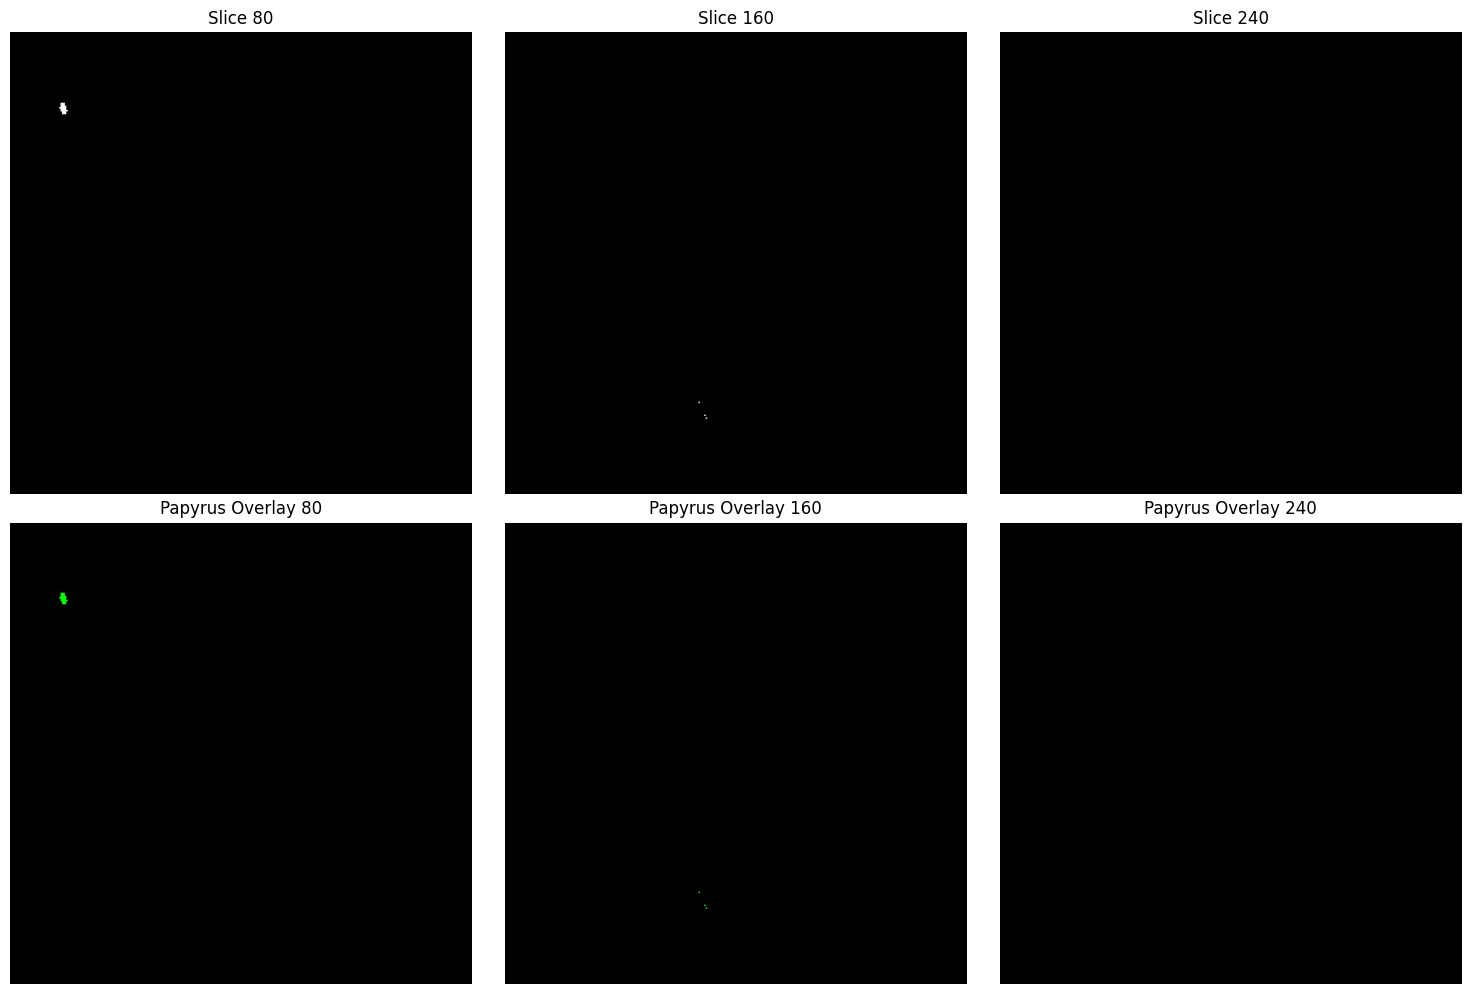


Prediction Statistics:
  Shape: (320, 320, 320)
  Background: 100.0%
  Papyrus:    0.0%
  Components: 17


In [12]:
# CELL 12: Visualization (Optional)
print("\nGenerating preview visualization...")

if processed_count > 0:
    # Load first prediction
    tif_files = sorted(cfg.OUTPUT_DIR.glob("*.tif"))
    sample_pred = tifffile.imread(str(tif_files[0]))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    z_indices = [
        sample_pred.shape[0] // 4,
        sample_pred.shape[0] // 2,
        3 * sample_pred.shape[0] // 4
    ]
    
    for i, z in enumerate(z_indices):
        # Raw prediction
        axes[0, i].imshow(sample_pred[z], cmap='gray', vmin=0, vmax=1)
        axes[0, i].set_title(f'Slice {z}')
        axes[0, i].axis('off')
        
        # Overlay
        overlay = np.zeros((*sample_pred[z].shape, 3))
        overlay[sample_pred[z] == 1] = [0, 1, 0]
        axes[1, i].imshow(overlay)
        axes[1, i].set_title(f'Papyrus Overlay {z}')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.savefig('prediction_preview.png', dpi=100, bbox_inches='tight')
    print("✓ Saved: prediction_preview.png")
    plt.show()
    
    # Stats
    print(f"\nPrediction Statistics:")
    print(f"  Shape: {sample_pred.shape}")
    print(f"  Background: {(sample_pred == 0).sum() / sample_pred.size * 100:.1f}%")
    print(f"  Papyrus:    {(sample_pred == 1).sum() / sample_pred.size * 100:.1f}%")
    print(f"  Components: {measure.label(sample_pred).max()}")